# Graph vs Flat — Honest Evidence Notebook

**Person 4 · SemanticSplat sprint · 2026-07-01**

**Dependencies** (once per venv): `pip install -r notebooks/requirements.txt`

Run from repo root or `notebooks/` — paths auto-detect `docs/benchmark_results/benchmark_default.json`.

## Scope (read first)

| Included | Excluded |
|----------|----------|
| Scene default only (Conference Hall demo) | Five captured PLY scenes — see **Part B** below |
| Measured infra + **estimated** LLM timing | Live provider-backed runs |
| Data from docs/benchmark_results/benchmark_default.json | Semantic accuracy / hit@k |
| 12 benchmark queries | ConceptGraphs / LangSplat comparison |

**Do not** use charts from this notebook to claim five-scene graph superiority.


In [1]:
from __future__ import annotations
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path('..').resolve() if (Path('..') / 'docs').exists() else Path('.').resolve()
BENCH_JSON = REPO / 'docs' / 'benchmark_results' / 'benchmark_default.json'
assert BENCH_JSON.exists(), f'Missing {BENCH_JSON}'

with BENCH_JSON.open(encoding='utf-8') as f:
    bench = json.load(f)

print('scene_id:', bench['scene_id'])
print('queries_run:', bench['queries_run'])
print('total_views:', bench['total_views'])
print('tree nodes:', bench['graph_stats']['node_count'])


scene_id: default
queries_run: 12
total_views: 19
tree nodes: 15


In [2]:
rows = []
for item in bench['results']:
    g, fl = item['graph'], item['flat']
    rows.append({
        'query': item['query'],
        'graph_tokens': g['input_tokens'],
        'flat_tokens': fl['input_tokens'],
        'graph_views': g['views_checked'],
        'flat_views': fl['views_checked'],
        'graph_calls': g['llm_calls'],
        'flat_calls': fl['llm_calls'],
        'graph_sec': g['timing']['total_sec'],
        'flat_sec': fl['timing']['total_sec'],
        'token_ratio': fl['input_tokens'] / max(g['input_tokens'], 1),
        'view_ratio': fl['views_checked'] / max(g['views_checked'], 1),
        'time_ratio': fl['timing']['total_sec'] / max(g['timing']['total_sec'], 1e-6),
    })

df = pd.DataFrame(rows)
df


,query,graph_tokens,flat_tokens,graph_views,flat_views,graph_calls,flat_calls,graph_sec,flat_sec,token_ratio,view_ratio,time_ratio
0,take me to the projector,19379,26587,13,19,17,20,146.99,196.93,1.371949,1.461538,1.339751
1,find the bar,2114,26547,1,19,4,20,16.50,196.64,12.557711,19.000000,11.917576
2,find the red sofa,5950,26567,4,19,7,20,44.95,196.78,4.465042,4.750000,4.377753
3,where is the exit sign?,2225,26587,1,19,4,20,17.29,196.92,11.949213,19.000000,11.389242
4,find the piano,2217,26547,1,19,4,20,17.24,196.64,11.974290,19.000000,11.406032
5,find all exit signs,12278,26567,8,19,11,20,91.56,196.78,2.163789,2.375000,2.149192
6,where is the screen in the conference room loc...,2034,26667,1,19,4,20,15.93,197.50,13.110619,19.000000,12.397991
7,find the projector in the ballroom,19413,26627,13,19,17,20,144.62,197.21,1.371607,1.461538,1.363643
8,where is the projection screen in the ballroom,2034,26667,1,19,4,20,15.93,197.49,13.110619,19.000000,12.397363
9,where is the screen in the conference room,2030,26647,1,19,4,20,15.90,197.35,13.126601,19.000000,12.411950


In [3]:
# Aggregate means (same method as benchmark report headline numbers)
agg = {
    'graph_tokens_mean': df['graph_tokens'].mean(),
    'flat_tokens_mean': df['flat_tokens'].mean(),
    'graph_views_mean': df['graph_views'].mean(),
    'flat_views_mean': df['flat_views'].mean(),
    'graph_sec_mean': df['graph_sec'].mean(),
    'flat_sec_mean': df['flat_sec'].mean(),
}
for k, v in agg.items():
    print(f'{k}: {v:.2f}')

print('token_reduction_x:', agg['flat_tokens_mean'] / agg['graph_tokens_mean'])
print('view_reduction_x:', agg['flat_views_mean'] / agg['graph_views_mean'])
print('time_speedup_x:', agg['flat_sec_mean'] / agg['graph_sec_mean'])


graph_tokens_mean: 6429.67
flat_tokens_mean: 26603.67
graph_views_mean: 4.00
flat_views_mean: 19.00
graph_sec_mean: 48.65
flat_sec_mean: 197.04
token_reduction_x: 4.13764321634092
view_reduction_x: 4.75
time_speedup_x: 4.049858696583026


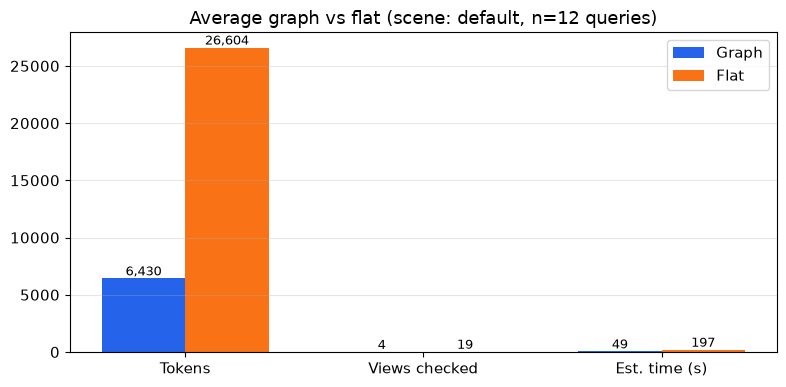

In [4]:
# Styling
plt.rcParams.update({'figure.figsize': (8, 4), 'font.size': 11})
BLUE, ORANGE = '#2563eb', '#f97316'

metrics = ['Tokens', 'Views checked', 'Est. time (s)']
graph_vals = [agg['graph_tokens_mean'], agg['graph_views_mean'], agg['graph_sec_mean']]
flat_vals = [agg['flat_tokens_mean'], agg['flat_views_mean'], agg['flat_sec_mean']]

x = range(len(metrics))
w = 0.35
fig, ax = plt.subplots()
ax.bar([i - w/2 for i in x], graph_vals, w, label='Graph', color=BLUE)
ax.bar([i + w/2 for i in x], flat_vals, w, label='Flat', color=ORANGE)
ax.set_xticks(list(x), metrics)
ax.set_title('Average graph vs flat (scene: default, n=12 queries)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (g, f) in enumerate(zip(graph_vals, flat_vals)):
    ax.text(i - w/2, g, f'{g:,.0f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + w/2, f, f'{f:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


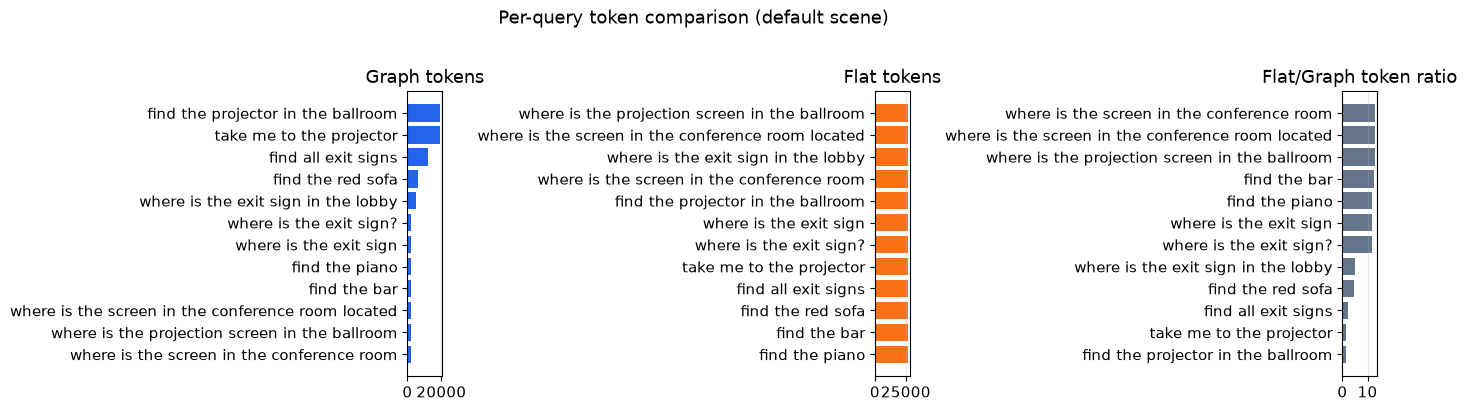

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, ['graph_tokens', 'flat_tokens', 'token_ratio'], ['Graph tokens', 'Flat tokens', 'Flat/Graph token ratio']):
    data = df.sort_values(col, ascending=False)
    ax.barh(data['query'], data[col], color=BLUE if 'graph' in col else ORANGE if 'flat' in col else '#64748b')
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Per-query token comparison (default scene)', y=1.02)
plt.tight_layout()
plt.show()


## Week 3 dataset status (not graph-vs-flat results)

Counts from docs/project/final_week3_acceptance.md — **coverage only**, not accuracy.


In [6]:
dataset_status = pd.DataFrame([
    {'metric': 'Captured scenes', 'value': 5},
    {'metric': 'Annotated views', 'value': 96},
    {'metric': 'Semantic items', 'value': 1046},
    {'metric': 'Five-scene stub queries', 'value': 40},
    {'metric': 'Stub results (schema-valid)', 'value': 40},
    {'metric': 'Live VLM results', 'value': 0},
    {'metric': 'Accuracy-eligible results', 'value': 0},
    {'metric': 'Graph-vs-flat on captured scenes', 'value': 'NOT RUN'},
])
dataset_status


,metric,value
0,Captured scenes,5
1,Annotated views,96
2,Semantic items,1046
3,Five-scene stub queries,40
4,Stub results (schema-valid),40
5,Live VLM results,0
6,Accuracy-eligible results,0
7,Graph-vs-flat on captured scenes,NOT RUN


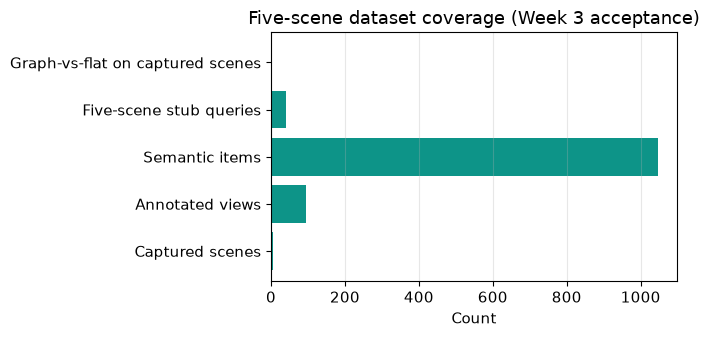

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
plot_df = dataset_status[dataset_status['metric'].str.contains('scene|item|view|query', case=False)]
nums = plot_df['value'].apply(lambda x: x if isinstance(x, (int, float)) else 0)
ax.barh(plot_df['metric'], nums, color='#0d9488')
ax.set_xlabel('Count')
ax.set_title('Five-scene dataset coverage (Week 3 acceptance)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## Timing model (disclosure)

Estimated seconds per query use the benchmark report formula:

	otal_sec = infra_sec + llm_calls * 0.35 + input_tokens / 140

This is **not** wall-clock time from a live API. See docs/benchmarks/benchmark_graph_vs_flat.md.

## Next notebook update

When Person 1 produces outputs/graph_vs_flat/<run_id>/metrics_summary.json, add a new section **Captured scenes — same-input benchmark** and keep this default section unchanged for audit trail.


---
## Part B — Five captured scenes (primary sprint result)

Source: outputs/graph_vs_flat/five_scene_graph_vs_flat_v2/metrics_summary.json

- **150 queries**, stub lexical mode, same semantic items for graph and flat
- Quality metrics: **125 queries** with verified expected_view_ids
- Manual ViewJSON labels = reference labels, not independent GT


In [ ]:
FIVE_SCENE_JSON = REPO / 'outputs' / 'graph_vs_flat' / 'five_scene_graph_vs_flat_v2' / 'metrics_summary.json'
assert FIVE_SCENE_JSON.exists(), FIVE_SCENE_JSON
five = json.loads(FIVE_SCENE_JSON.read_text(encoding='utf-8'))
summary = five['summary']
avg = summary['averages']
qual = summary['quality']
print('queries:', summary['query_count'])
print('gt queries:', summary['gt_query_count'])
print('views savings %:', avg['savings_views_pct'])
print('token savings %:', avg['savings_tokens_pct'])
print('hit@1 graph/flat:', qual['hit_at_1_graph'], qual['hit_at_1_flat'])


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

five_rows = [
    {'method': 'Graph', 'views': avg['graph_views_checked'], 'tokens': avg['graph_input_tokens'], 'ms': avg['graph_elapsed_ms']},
    {'method': 'Flat', 'views': avg['flat_views_checked'], 'tokens': avg['flat_input_tokens'], 'ms': avg['flat_elapsed_ms']},
]
five_df = pd.DataFrame(five_rows)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, col, title in zip(axes, ['views', 'tokens', 'ms'], ['Views checked', 'Input tokens', 'Infra elapsed (ms)']):
    ax.bar(five_df['method'], five_df[col], color=[BLUE, ORANGE])
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Five-scene graph vs flat (n=150 queries, stub lexical)', y=1.02)
plt.tight_layout()
plt.show()
five_df


In [ ]:
qual_df = pd.DataFrame([
    {'metric': 'hit@1', 'graph': qual['hit_at_1_graph'], 'flat': qual['hit_at_1_flat']},
    {'metric': 'hit@3', 'graph': qual['hit_at_3_graph'], 'flat': qual['hit_at_3_flat']},
])
fig, ax = plt.subplots(figsize=(5, 3))
x = range(len(qual_df))
w = 0.35
ax.bar([i-w/2 for i in x], qual_df['graph'], w, label='Graph', color=BLUE)
ax.bar([i+w/2 for i in x], qual_df['flat'], w, label='Flat', color=ORANGE)
ax.set_xticks(list(x), qual_df['metric'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Rate')
ax.set_title('Quality on 125 GT-verified queries')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
qual_df
